# Reweighting a STARLING ensemble against SAXS with `COPER`

`soursop.sscoper.COPER` (Convex Optimization for Ensemble Reweighting; Leung et al., *JCTC*
2016) is an alternative to BME. Where BME minimises `cost + θ·D_KL` with a tunable penalty
`θ`, **COPER maximises the ensemble entropy subject to a *hard* goodness-of-fit constraint**:

$$\max_{w}\; S(w)\quad\text{subject to}\quad \chi^2(w) \le \chi^2_{\mathrm{limit}},\;\; w_i \ge 0,\;\; \textstyle\sum_i w_i = 1.$$

Two consequences make COPER distinctive:

1. **You specify the target fit directly** (e.g. "reach `χ² ≤ 1`") rather than dialling an
   abstract penalty, and COPER returns the *most conservative* (highest-entropy) ensemble
   that reaches it.
2. **It reports infeasibility.** If no reweighting of the prior can satisfy the requested
   `χ²`, COPER tells you so — a useful signal that the model and data are genuinely
   inconsistent.

Like BME (but unlike `BMECustom`), COPER compares the computed and experimental values
*directly*, so we first put the computed scattering on the experimental scale. (`iCOPER`
fits that scale iteratively; here we set it once from the prior, as is standard.)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import glob

import numpy as np
import matplotlib.pyplot as plt

from soursop.sscoper import COPER
from soursop.ssbme import ExperimentalObservable
from soursop.sstrajectory import SSTrajectory

DATA_DIR = Path(".")
SAXS_FRAME_DIR = DATA_DIR / "saxs_frames"

## 1. Load the data and build the observables

As in the `BMECustom` notebook: load the experimental curve and the per-frame computed
profiles, interpolate onto a common `q`-grid, and pre-scale the computed curves onto the
experimental scale. Each `q`-point then becomes one `ExperimentalObservable` (value +
uncertainty), and the per-frame computed intensities are the `calculated_values` matrix.

In [2]:
exp = np.loadtxt(DATA_DIR / "pnt.dat")
q_exp, I_exp_raw, sigma_exp_raw = exp[:, 0], exp[:, 1], exp[:, 2]

frame_files = sorted(glob.glob(str(SAXS_FRAME_DIR / "frame_*.dat")))
q_calc = np.loadtxt(frame_files[0])[:, 0]
calc = np.array([np.loadtxt(f)[:, 1] for f in frame_files])
n_frames = calc.shape[0]

# common grid
mask = (q_calc >= q_exp.min()) & (q_calc <= q_exp.max())
q = q_calc[mask]
I_exp = np.interp(q, q_exp, I_exp_raw)
sigma_exp = np.interp(q, q_exp, sigma_exp_raw)
C_raw = calc[:, mask]


def optimal_scale(avg, experiment, sigma):
    return np.sum(avg * experiment / sigma**2) / np.sum(avg**2 / sigma**2)


# pre-scale onto the experimental scale using the prior average
alpha0 = optimal_scale(C_raw.mean(axis=0), I_exp, sigma_exp)
C = alpha0 * C_raw

observables = [ExperimentalObservable(value=I_exp[k], uncertainty=sigma_exp[k])
               for k in range(q.size)]
print(f"{n_frames} conformers, {q.size} q-point observables")
print(f"prior reduced chi^2 (at fixed scale): "
      f"{np.mean(((C.mean(axis=0) - I_exp) / sigma_exp) ** 2):.2f}")

600 conformers, 76 q-point observables
prior reduced chi^2 (at fixed scale): 4.40


## 2. Fit at a target `χ²`

`COPER.fit(chi2_limit=...)` runs the two-step procedure of Leung et al.: (1) minimise `χ²` to
test feasibility, then (2) maximise entropy subject to `χ² ≤ chi2_limit`. The verbose output
reports both steps, plus the entropy reduction `ΔS` and the mean free-energy change
`⟨ΔG⟩/kT` of the reweighting.

In [3]:
coper = COPER(observables, C)
result = coper.fit(chi2_limit=1.5)
print()
print(result)

COPER Optimization
  Frames: 600, Observables: 76, Groups: 1
  Chi-squared limit:   1.5
  Chi-squared initial (max over groups): 4.4026
  Step 1 chi^2 (max over groups): 0.7314
  Feasible (<= limit + tol): True
  Step 2 chi^2 (max over groups): 1.5000
  Optimization successful: True

COPER Result [SUCCESS, feasible]
  Chi-squared initial: 4.4026
  Chi-squared min:     0.7314
  Chi-squared final:   1.5000
  Chi-squared limit:   1.5000
  phi (effective fraction): 0.6051
  delta_S:             -0.5024
  <delta_G>/kT:        0.5024
  Iterations: 36


## 3. Feasibility: when the data can't be fit

COPER's signature feature is telling you when a target is *unreachable*. The step-1 χ²
minimisation found the smallest χ² any reweighting of this ensemble can achieve; ask for
less than that and COPER reports `feasible=False` and returns the closest it could get,
rather than silently over-fitting.

In [4]:
chi2_floor = result.chi_squared_min      # smallest achievable chi^2 (from step 1)
print(f"smallest achievable chi^2 for this ensemble: {chi2_floor:.3f}\n")

infeasible = coper.fit(chi2_limit=0.5 * chi2_floor, verbose=False)
print(f"requested chi2_limit = {0.5 * chi2_floor:.3f}")
print(f"  feasible: {infeasible.feasible}")
print(f"  message:  {infeasible.message}")

smallest achievable chi^2 for this ensemble: 0.731



requested chi2_limit = 0.366
  feasible: False
  message:  Data infeasible at chi2_limit=0.3657: minimum max-group chi^2 (0.7314) exceeds the limit.


## 4. Choose the `χ²` limit with a scan (L-curve)

`scan_chi2_limit` is COPER's analogue of BME's `theta` scan: it sweeps the χ² limit and finds
the knee of entropy-loss vs fit-quality. (Thanks to COPER's softmax-reparameterised solver
this is now a matter of seconds.)

selected chi2_limit (knee): 1.599


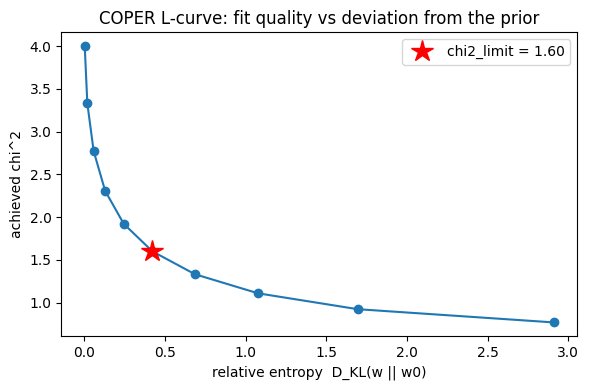

In [5]:
scan = coper.scan_chi2_limit(chi2_limits=(chi2_floor * 1.05, 4.0), n_points=10, verbose=False)
print(f"selected chi2_limit (knee): {scan.optimal_chi2_limit:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
feas = scan.feasible_mask
ax.plot(scan.kl_divergence_values[feas], scan.chi_squared_values[feas], "o-")
ax.plot(scan.kl_divergence_values[scan.optimal_idx],
        scan.chi_squared_values[scan.optimal_idx],
        "r*", ms=16, label=f"chi2_limit = {scan.optimal_chi2_limit:.2f}")
ax.set_xlabel("relative entropy  D_KL(w || w0)")
ax.set_ylabel("achieved chi^2")
ax.set_title("COPER L-curve: fit quality vs deviation from the prior")
ax.legend()
fig.tight_layout()

In [6]:
result = coper.fit(chi2_limit=scan.optimal_chi2_limit, verbose=False)
result.print_diagnostics()


COPER DIAGNOSTIC REPORT

Optimization Status: `gtol` termination condition is satisfied.
Success: True    Feasible: True
Iterations: 30

Chi-squared (max over groups):
  Initial                                  4.4026
  Step-1 minimum                           0.7314
  Final                                    1.5992
  Limit                                    1.5992
  Improvement                              2.8034 (63.7%)

Information content / diversity:
  Phi (entropy fraction)                   0.6561
  N_eff (entropy-based)                     393.6  / 600
  N_eff (1/sum w^2, Renyi-2)                264.1  / 600
  delta_S                                 -0.4215
  <delta_G>/kT                             0.4215

Weight distribution:
  Min                                    7.72e-05
  Max                                    1.94e-02
  Std Dev                                1.88e-03
  Range (orders of magnitude)                 2.4
  Reweighting factor min                  0.04634
  R

## 5. The reweighted scattering and weights

As with the other reweighters, compare the prior (uniform) and COPER-reweighted average
profiles against experiment, and inspect the posterior weights.

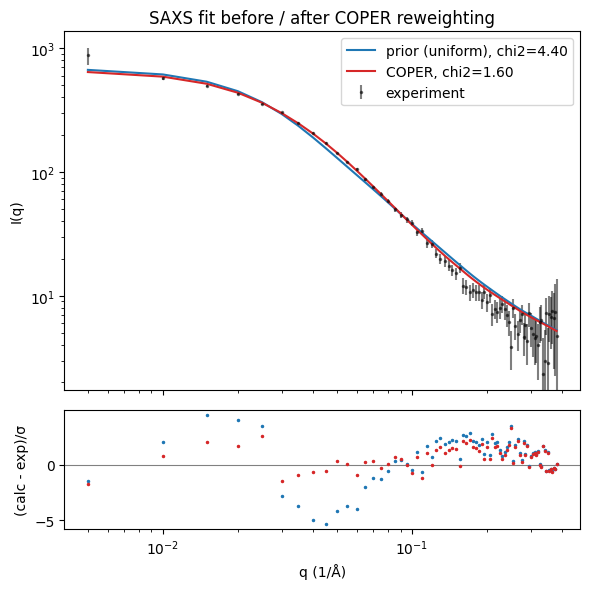

In [7]:
avg_prior = result.initial_weights @ C
avg_coper = result.weights @ C

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.errorbar(q, I_exp, yerr=sigma_exp, fmt="k.", ms=3, alpha=0.5, label="experiment")
ax1.plot(q, avg_prior, "C0-", label=f"prior (uniform), chi2={result.chi_squared_initial:.2f}")
ax1.plot(q, avg_coper, "C3-", label=f"COPER, chi2={result.chi_squared_final:.2f}")
ax1.set_yscale("log")
ax1.set_ylabel("I(q)")
ax1.set_title("SAXS fit before / after COPER reweighting")
ax1.legend()
ax2.axhline(0, color="gray", lw=0.8)
ax2.plot(q, (avg_prior - I_exp) / sigma_exp, "C0.", ms=3)
ax2.plot(q, (avg_coper - I_exp) / sigma_exp, "C3.", ms=3)
ax2.set_xscale("log")
ax2.set_xlabel("q (1/\u00c5)")
ax2.set_ylabel("(calc - exp)/\u03c3")
fig.tight_layout()

phi (effective fraction): 0.656  -> ~394/600 frames
entropy loss  -delta_S      = 0.421
mean <delta_G>/kT (= D_KL)  = 0.421


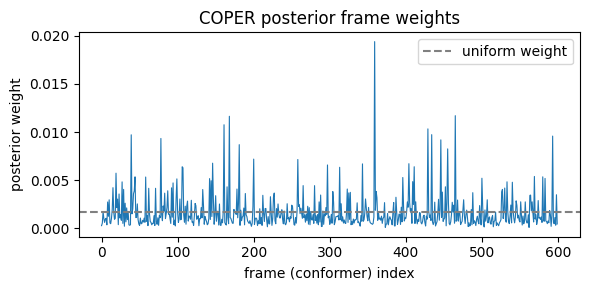

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(result.weights, lw=0.8)
ax.axhline(1.0 / n_frames, color="gray", ls="--", label="uniform weight")
ax.set_xlabel("frame (conformer) index")
ax.set_ylabel("posterior weight")
ax.set_title("COPER posterior frame weights")
ax.legend()
fig.tight_layout()

print(f"phi (effective fraction): {result.phi:.3f}  -> ~{result.phi * n_frames:.0f}/{n_frames} frames")
print(f"entropy loss  -delta_S      = {-result.delta_S:.3f}")
print(f"mean <delta_G>/kT (= D_KL)  = {result.mean_delta_G_kT:.3f}")

## 6. Use the weights with SOURSOP

COPER weights are an ordinary per-frame probability vector and flow into any SOURSOP
observable via `weights=`.

<Rg> prior (uniform):  57.10 A
<Rg> COPER-reweighted: 56.30 A


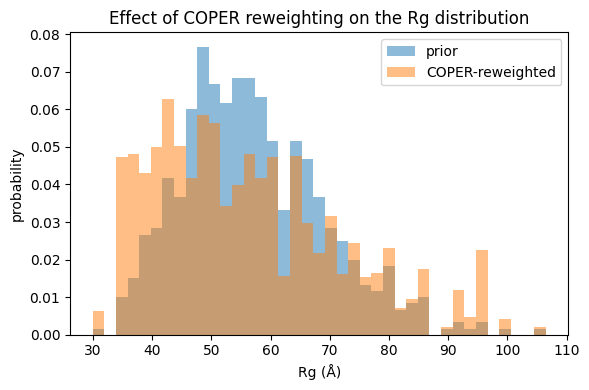

In [9]:
protein = SSTrajectory(str(DATA_DIR / "pnt_STARLING.xtc"),
                       str(DATA_DIR / "pnt_STARLING.pdb")).proteinTrajectoryList[0]
rg = protein.get_radius_of_gyration()
print(f"<Rg> prior (uniform):  {rg.mean():.2f} A")
print(f"<Rg> COPER-reweighted: {protein.get_radius_of_gyration(weights=result.weights):.2f} A")

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(rg.min(), rg.max(), 40)
ax.hist(rg, bins=bins, weights=np.full(n_frames, 1.0 / n_frames), alpha=0.5, label="prior")
ax.hist(rg, bins=bins, weights=result.weights, alpha=0.5, label="COPER-reweighted")
ax.set_xlabel("Rg (\u00c5)")
ax.set_ylabel("probability")
ax.set_title("Effect of COPER reweighting on the Rg distribution")
ax.legend()
fig.tight_layout()

## Notes

- **COPER vs BME.** They optimise the same convex trade-off from opposite ends — BME fixes the
  penalty `θ` and reads off the χ²; COPER fixes the χ² and reads off the penalty implicitly.
  At a matched operating point they return essentially the *same* weights (see the comparison
  notebook). Choose COPER when it is more natural to state the target fit, or when you want the
  explicit feasibility test.
- **Feasibility is information.** `feasible=False` means the prior ensemble simply cannot
  reproduce the data to the requested χ² — investigate the model (or the data/errors) rather
  than forcing a fit.
- **Scale.** We fixed the SAXS scale once from the prior. If the scale is uncertain, use
  `iCOPER`, which alternates a scale/offset fit with COPER (analogous to iBME).
- **Per-data-type constraints.** Passing `group=` on each `ExperimentalObservable` lets COPER
  impose a separate χ² limit per data type (e.g. SAXS vs NOE), matching the multi-dataset
  formulation in the original paper.
- **Performance.** COPER enforces the simplex with a softmax reparameterisation, so even a
  full SAXS profile over hundreds of conformers fits in seconds and `scan_chi2_limit` is cheap.